In [7]:
# import things
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras.backend as K
from keras.models import Model
import keras.backend as K
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Lambda
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import EarlyStopping

In [8]:
# REQUIREMENT: Do not add code from Tasks 2 or 4
# REQUIREMENT: All dataset prep (crop/pad/patch/directory structure) must be finalize before attempting this task.
patch_size = 256
patch_dir = r'C:\Users\vikku\OneDrive\Documenten\Buas\2024-25b-fai2-adsai-ViktoriaKubisova231781\dataset_256_filtered_augmented'

In [9]:
def f1(y_true, y_pred):
    def recall_m(y_true, y_pred):
        TP = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        Positives = K.sum(K.round(K.clip(y_true, 0, 1)))
        recall = TP / (Positives+K.epsilon())
        return recall
    
    def precision_m(y_true, y_pred):
        TP = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        Pred_Positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
        precision = TP / (Pred_Positives+K.epsilon())
        return precision
    
    precision, recall = precision_m(y_true, y_pred), recall_m(y_true, y_pred)
    
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

In [10]:
# Define a new loss function
# Dice Loss
def dice_loss(y_true, y_pred):
    smooth = 1e-6
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# Combo Loss: Binary Crossentropy + Dice
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

In [11]:
# Define U-Net
def simple_unet_model(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS):
    # Build the model
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    s = inputs

    # Contraction path
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(s)
    c1 = Dropout(0.1)(c1)
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)
    
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = Dropout(0.1)(c2)
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)
     
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = Dropout(0.2)(c3)
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)
     
    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = Dropout(0.2)(c4)
    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = MaxPooling2D(pool_size=(2, 2))(c4)
     
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = Dropout(0.3)(c5)
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)
    
    # Expansive path 
    u6 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)
     
    u7 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)
     
    u8 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = Dropout(0.1)(c8)
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)
     
    u9 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1], axis=3)
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = Dropout(0.1)(c9)
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)
     
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)
     
    model = Model(inputs=[inputs], outputs=[outputs])
    model.compile(optimizer='adam', loss=bce_dice_loss, metrics=['accuracy', f1])
    model.summary()
    
    return model

In [12]:
# Build U-Net
# REQUIREMENT: Model summary must be visible
model = simple_unet_model(patch_size, patch_size, 1)

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 256, 256, 16  160         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 dropout (Dropout)              (None, 256, 256, 16  0           ['conv2d[0][0]']                 
                                )                                                             

In [13]:
# Setup a generator for training
# Training images
train_image_datagen = ImageDataGenerator(rescale=1./255)
train_image_generator = train_image_datagen.flow_from_directory(
    f'{patch_dir}/train_images',
    target_size=(patch_size, patch_size),
    batch_size=32,
    class_mode=None,
    color_mode='grayscale',
    seed=42)

# Training masks
train_mask_datagen = ImageDataGenerator()
train_mask_generator = train_mask_datagen.flow_from_directory(
    f'{patch_dir}/train_masks',
    target_size=(patch_size, patch_size),
    batch_size=32,
    class_mode=None,
    color_mode='grayscale',
    seed=42)

# Combine image and mask generators
train_generator = zip(train_image_generator, train_mask_generator)

Found 113373 images belonging to 1 classes.
Found 113373 images belonging to 1 classes.


In [14]:
# Setup a generator for validation
# Validation images
val_image_datagen = ImageDataGenerator(rescale=1./255)
val_image_generator = val_image_datagen.flow_from_directory(
    f'{patch_dir}/val_images',
    target_size=(patch_size, patch_size),
    batch_size=32,
    class_mode=None,
    color_mode='grayscale',  # Changed from 'rgb' to 'grayscale'
    seed=42
)

# Validation masks
val_mask_datagen = ImageDataGenerator()
val_mask_generator = val_mask_datagen.flow_from_directory(
    f'{patch_dir}/val_masks',
    target_size=(patch_size, patch_size),
    batch_size=32,
    class_mode=None,
    color_mode='grayscale',
    seed=42
)

# Combine val image and mask generators
val_generator = zip(val_image_generator, val_mask_generator)

Found 33957 images belonging to 1 classes.
Found 33957 images belonging to 1 classes.


In [15]:
# EarlyStopping()
from keras.callbacks import EarlyStopping
cb = EarlyStopping(monitor='val_loss',
                   patience=3,
                   restore_best_weights='True',
                   mode='min',
                   verbose=1)

In [16]:
img_batch, mask_batch = next(train_generator)
print("Image batch shape:", img_batch.shape)
print("Mask batch shape:", mask_batch.shape)

Image batch shape: (32, 256, 256, 1)
Mask batch shape: (32, 256, 256, 1)


In [17]:
print("Train image batches:", len(train_image_generator))
print("Train mask batches :", len(train_mask_generator))

Train image batches: 3543
Train mask batches : 3543


In [18]:
# This is where the magic happens
# REQUIREMENT: The epoch logs must be visible showing validation loss and validation f1.
batch_size = 32
validation_steps = (val_image_generator.samples // batch_size) // 2  # Use only 50% of val set

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_image_generator),
    epochs=30,
    validation_data=val_generator,
    validation_steps=validation_steps,
    callbacks=[cb]
)

Epoch 1/30
3543/3543 [==============================] - 1021s 285ms/step - loss: 0.2767 - accuracy: 0.9903 - f1: 0.7717 - val_loss: 0.1954 - val_accuracy: 0.9982 - val_f1: 0.8191
Epoch 2/30
3543/3543 [==============================] - 971s 274ms/step - loss: 0.2096 - accuracy: 0.9922 - f1: 0.8283 - val_loss: 0.2024 - val_accuracy: 0.9980 - val_f1: 0.8121
Epoch 3/30
3543/3543 [==============================] - 988s 279ms/step - loss: 0.2018 - accuracy: 0.9925 - f1: 0.8344 - val_loss: 0.1831 - val_accuracy: 0.9982 - val_f1: 0.8311
Epoch 4/30
3543/3543 [==============================] - 969s 274ms/step - loss: 0.1975 - accuracy: 0.9927 - f1: 0.8378 - val_loss: 0.1833 - val_accuracy: 0.9982 - val_f1: 0.8301
Epoch 5/30
3543/3543 [==============================] - 994s 281ms/step - loss: 0.1947 - accuracy: 0.9927 - f1: 0.8400 - val_loss: 0.1799 - val_accuracy: 0.9983 - val_f1: 0.8336
Epoch 6/30
3543/3543 [==============================] - 1066s 301ms/step - loss: 0.1923 - accuracy: 0.9928 - 

1/1 [==============================] - 0s 62ms/step


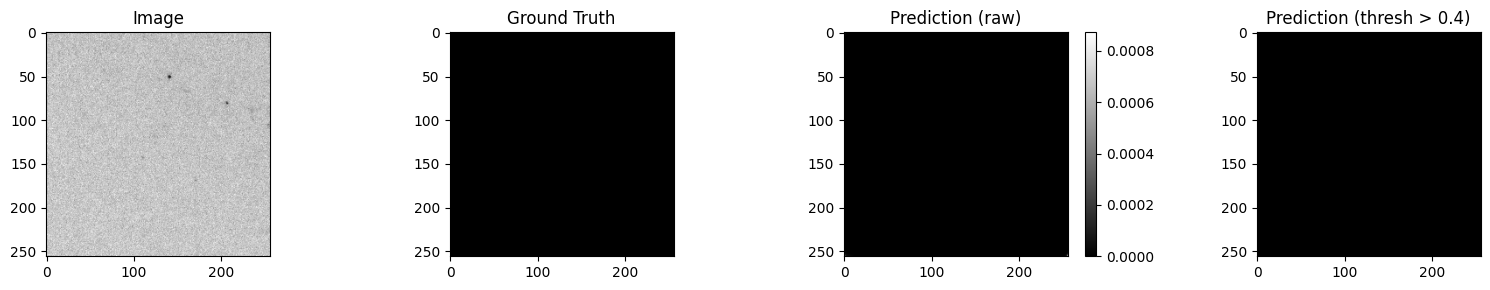

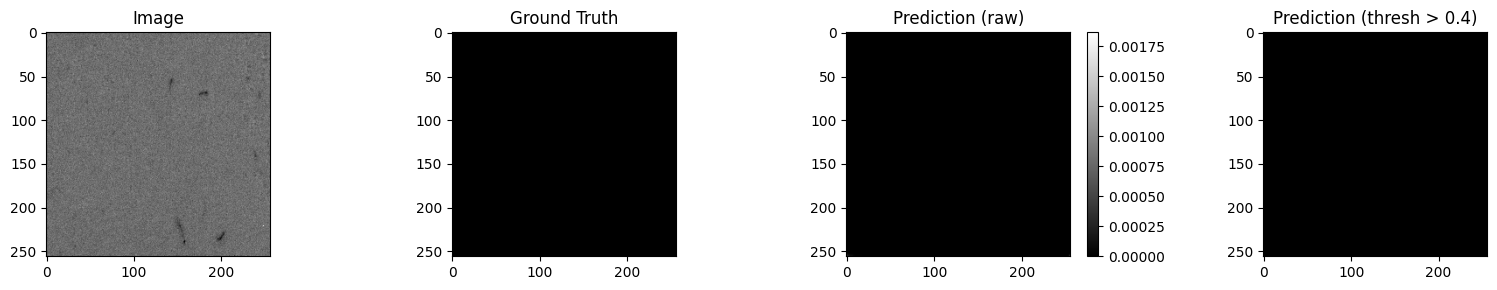

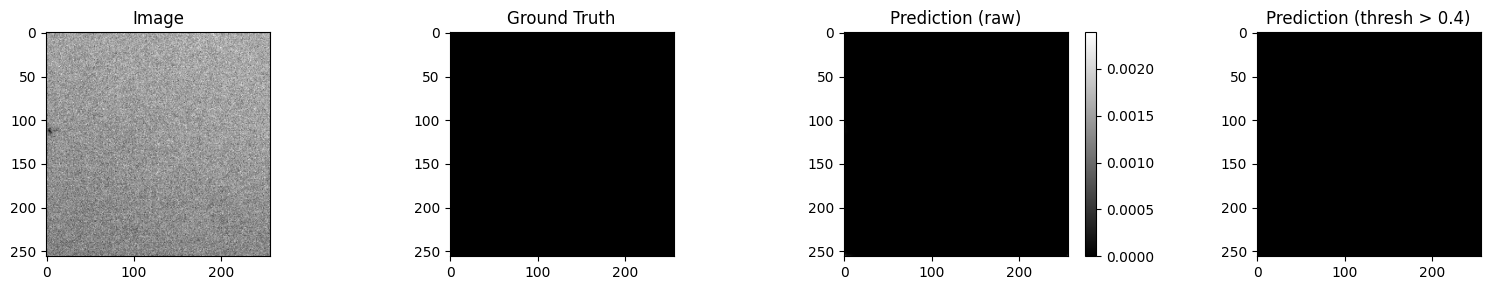

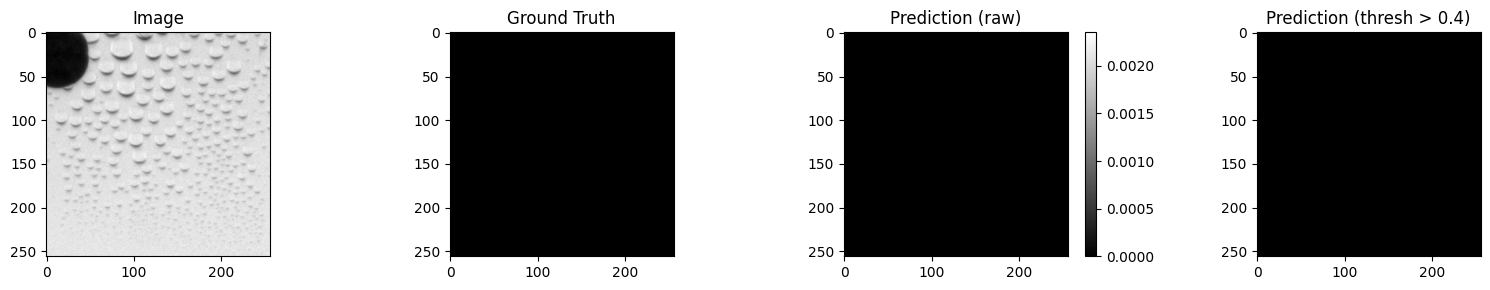

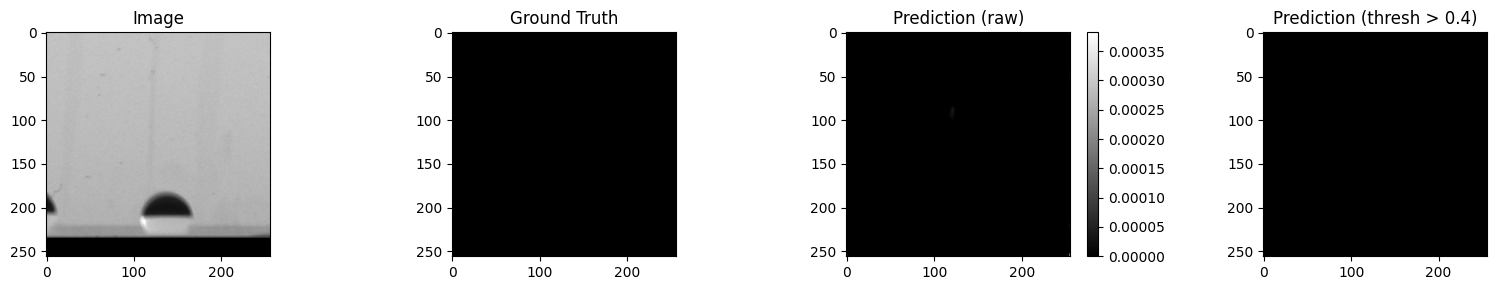

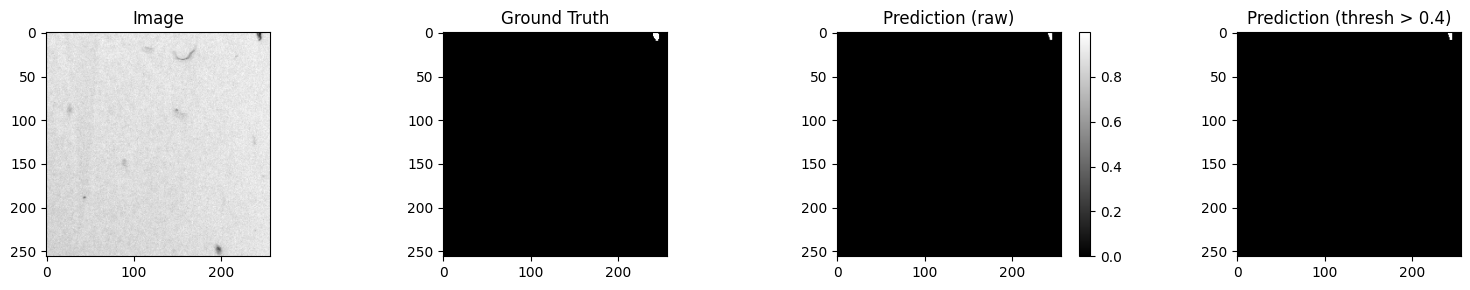

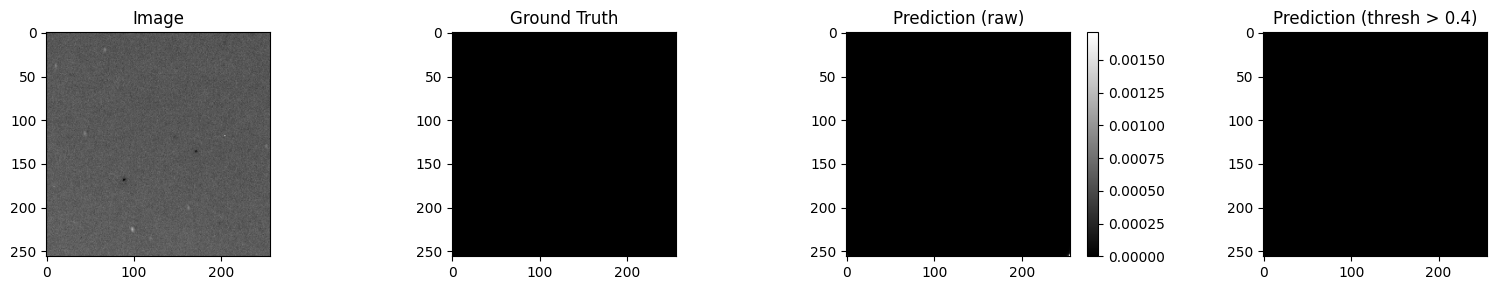

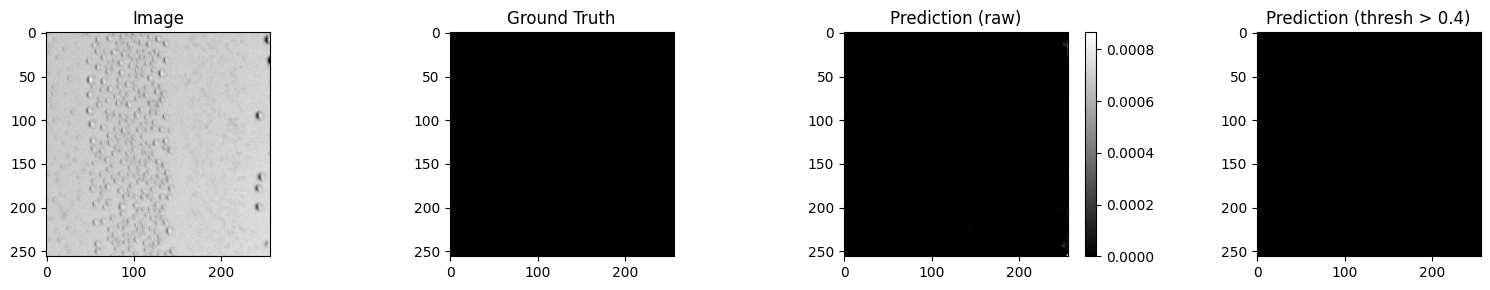

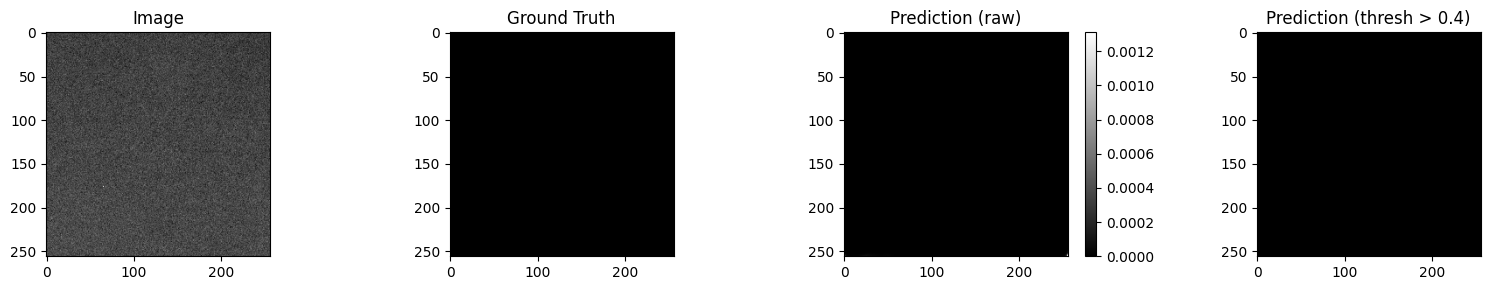

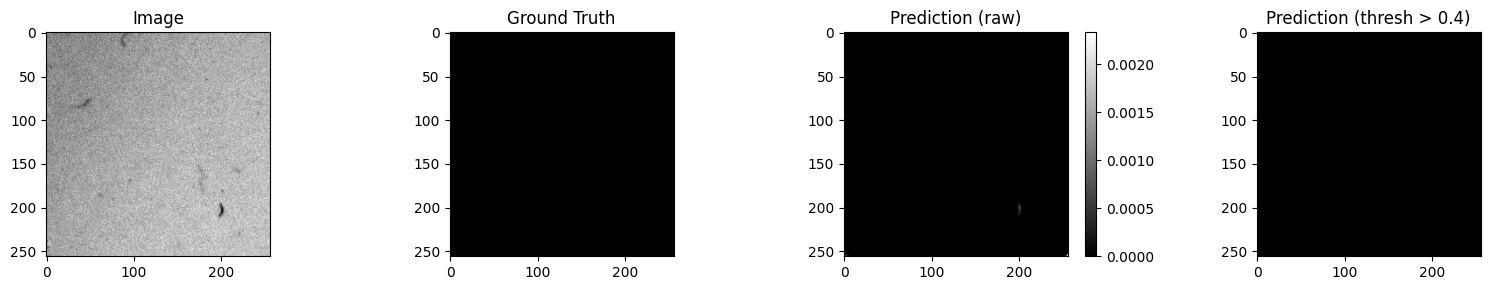

In [24]:
import matplotlib.pyplot as plt

images, masks = next(val_generator)
preds = model.predict(images)

for i in range(10):
    plt.figure(figsize=(16, 3))
    
    plt.subplot(1, 4, 1)
    plt.title("Image")
    plt.imshow(images[i].squeeze(), cmap='gray')

    plt.subplot(1, 4, 2)
    plt.title("Ground Truth")
    plt.imshow(masks[i].squeeze(), cmap='gray')

    plt.subplot(1, 4, 3)
    plt.title("Prediction (raw)")
    plt.imshow(preds[i].squeeze(), cmap='gray')
    plt.colorbar()

    plt.subplot(1, 4, 4)
    plt.title("Prediction (thresh > 0.4)")
    plt.imshow((preds[i].squeeze() > 0.5).astype(np.uint8), cmap='gray')

    plt.tight_layout()
    plt.show()

In [20]:
# REQUIREMENT: Save your model, it is a deliverable
# REQUIREMENT: naming convention 'studentname_studentnumber_unet_model_patchsizepx.h5'
example_file_name = f'10_viktoria_231781_unet_model_{patch_size}px.h5'
print(example_file_name)
model.save(example_file_name)

10_viktoria_231781_unet_model_256px.h5


In [21]:
# REQUIREMENT: Run and display the output of this cell.
# REQUIREMENT: Do not change the code.
best_val_loss = min(history.history['val_loss'])
best_val_f1 = max(history.history['val_f1'])
print(f"Best validation loss: {best_val_loss}")
print(f"Best validation f1: {best_val_f1}")

Best validation loss: 0.17245595157146454
Best validation f1: 0.8398988246917725


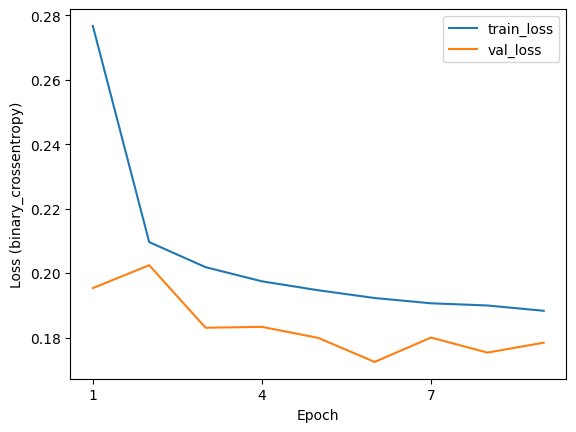

In [22]:
# REQUIREMENT: Run and display the output of this cell.
# REQUIREMENT: Do not change the code.
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = np.arange(1, len(loss) + 1)

plt.plot(epochs, loss, label='train_loss')
plt.plot(epochs, val_loss, label='val_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss (binary_crossentropy)')
_ = plt.xticks(np.arange(1, len(loss) + 1, 3))

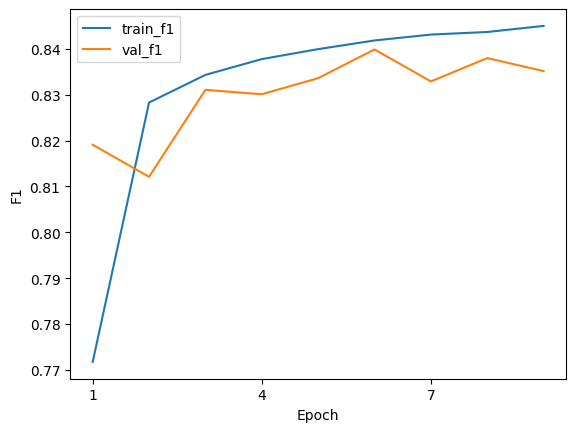

In [23]:
# REQUIREMENT: Run and display the output of this cell.
# REQUIREMENT: Do not change the code.
train_f1 = history.history['f1']
val_f1 = history.history['val_f1']

epochs = np.arange(1, len(train_f1) + 1)

plt.plot(epochs, train_f1, label='train_f1')
plt.plot(epochs, val_f1, label='val_f1')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('F1')
_ = plt.xticks(np.arange(1, len(loss) + 1, 3))